# 02. Valuation Model

This notebook builds and evaluates a supervised machine learning model to estimate flat asking prices in Barcelona using property characteristics and location-based information.

The objective is not only to obtain predictive performance, but also to understand which variables contribute most to estimated listing value and where the model presents higher uncertainty.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.paths import PROCESSED_DIR
from src.modeling.features import create_modeling_dataset
from src.modeling.train import train_baseline_model, train_random_forest_model, train_xgboost_model, optimize_xgboost_model
from src.modeling.evaluate import regression_metrics, metrics_table, prediction_results
from src.modeling.explain import feature_importance_table, grouped_feature_importance

## 1. Load data

The valuation model uses the processed dataset generated in the market snapshot module.

In [2]:
df = pd.read_csv(PROCESSED_DIR / "listings_processed.csv")

print(df.shape)
df.head()

(4438, 96)


,id,type,subtype,external_contract,invalid,new,advertiser,description,value,reduced,...,Bodega,Sauna,Cuarto lavado plancha,Energía Solar,Muebles de diseño,Música ambiental,Pista de Tenis,Porche cubierto,Sala de cine,price_per_sqm
0,181424803,2,1,False,False,False,BARNAQUATRE,Piso reformado a estrenar de cuatro habitacion...,475000,0,...,False,False,False,False,NaN,NaN,False,NaN,NaN,5163.043478
1,181170834,2,1,False,False,False,SANTA TERESA EXPORTACIONES SL.,Situado en una de las zonas más céntricas de B...,655000,35000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,6359.223301
2,181107559,2,1,False,False,False,MONIKA RÜSCH,Fantástica oportunidad de venta en una de las ...,395000,0,...,False,False,False,False,NaN,NaN,False,NaN,NaN,7452.830189
3,177615105,2,1,False,False,False,Inmuebla Retail Sociedad Limitada,Se vende un piso de 100 m2 con 2 habitaciones ...,495000,55000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,4500.000000
4,181799186,2,1,False,False,False,GAUDI HOUSE,Gaudi House tiene el agrado de presentarles es...,226000,10000,...,False,False,False,False,NaN,NaN,False,NaN,NaN,2790.123457


## 2. Modeling dataset preparation

For the valuation model, observations without neighborhood information are excluded because neighborhood is one of the main explanatory factors in real estate valuation.

The feature set combines:

- physical property characteristics
- energy and environmental indicators
- floor information
- selected amenities
- neighborhood information

Categorical variables are one-hot encoded before model training.

In [3]:
X_encoded, y, df_model = create_modeling_dataset(df)

print(X_encoded.shape, y.shape)
display(X_encoded.head())

(4361, 115) (4361,)


,rooms,bathrooms,surface,energy_value,environment_value,elevator,Aire acondicionado,Piscina,level8_Barri_Gotic,level8_Barri_de_les_Corts,...,floor_desc_7planta,floor_desc_8planta,floor_desc_9planta,floor_desc_Apartirdela15planta,floor_desc_Bajos,floor_desc_Entresuelo,floor_desc_Otro,floor_desc_Principal,floor_desc_Sotano,floor_desc_Subsotano
0,4,2,92,95.0,20.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,2,103,125.0,24.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,1,53,31.0,148.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,1,110,159.0,36.0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,3,1,81,109.0,35.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 3. Exploratory Data Analysis

Before training the model, this section reviews the most relevant patterns between the target variable and the main explanatory variables.

The purpose of this EDA is to validate the modeling logic and support the feature selection process.

### 3.1 Target variable

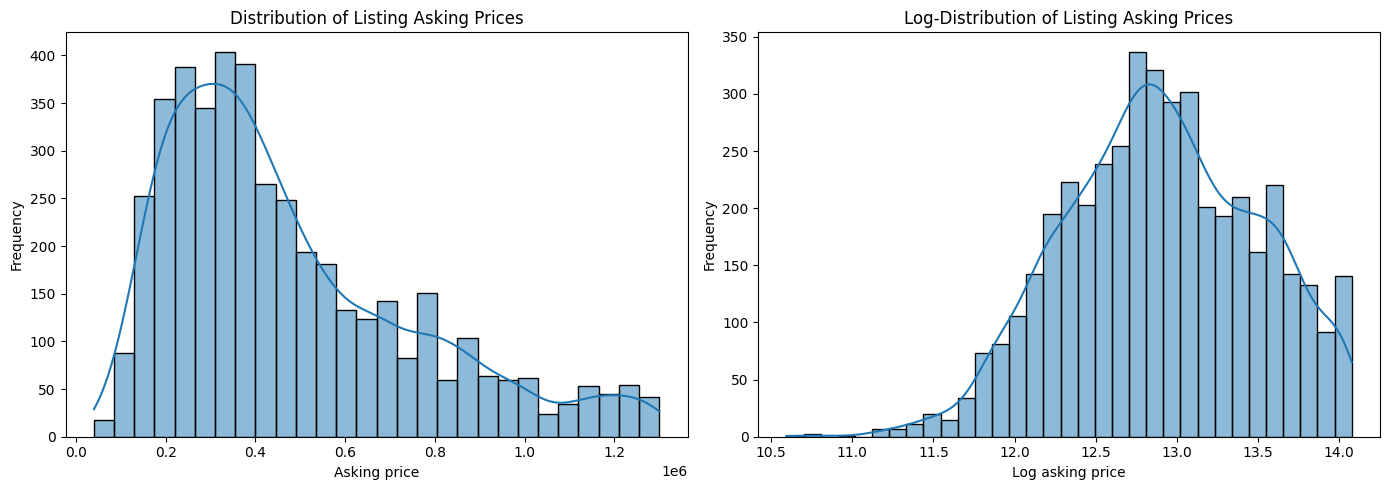

Mean asking price: 474,685 €
Median asking price: 395,000 €


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_model["value"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Listing Asking Prices")
axes[0].set_xlabel("Asking price")
axes[0].set_ylabel("Frequency")

sns.histplot(np.log(df_model["value"]), kde=True, ax=axes[1])
axes[1].set_title("Log-Distribution of Listing Asking Prices")
axes[1].set_xlabel("Log asking price")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean asking price: {df_model['value'].mean():,.0f} €")
print(f"Median asking price: {df_model['value'].median():,.0f} €")

### 3.2 Relationship between surface and price

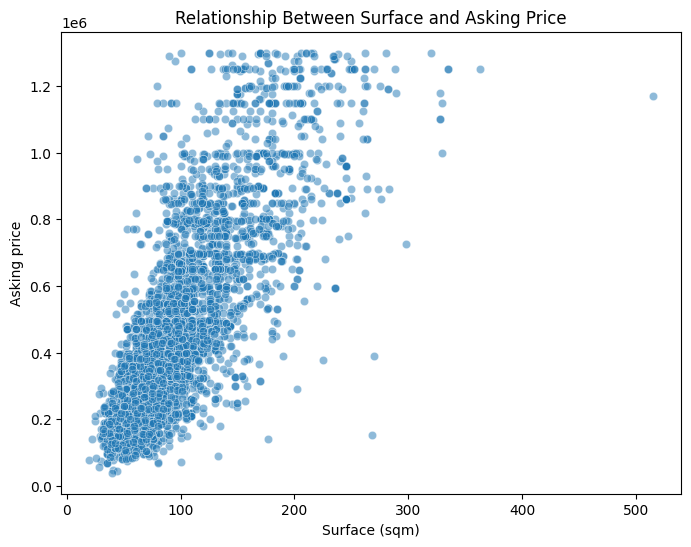

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_model, x="surface", y="value", alpha=0.5)
plt.title("Relationship Between Surface and Asking Price")
plt.xlabel("Surface (sqm)")
plt.ylabel("Asking price")
plt.show()

### 3.3 Surface and price by district

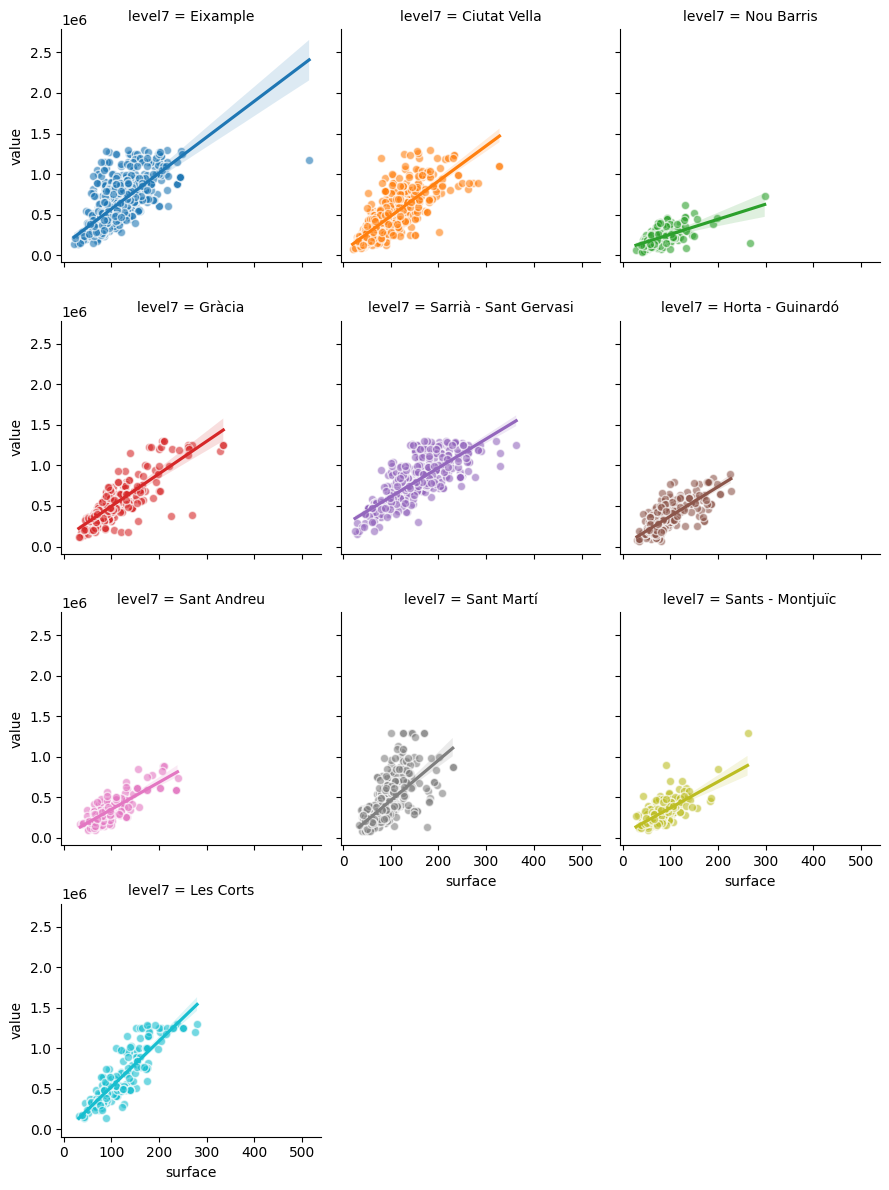

In [6]:
if "level7" in df_model.columns:
    sns.lmplot(
        data=df_model,
        x="surface",
        y="value",
        col="level7",
        hue="level7",
        scatter_kws={"edgecolor": "w", "alpha": 0.6},
        col_wrap=3,
        height=3,
    )
    plt.show()

### 3.4 Categorical variables and price

Boxplots are used to compare asking price distributions across categorical variables. This helps identify variables that may capture meaningful differences in property value.

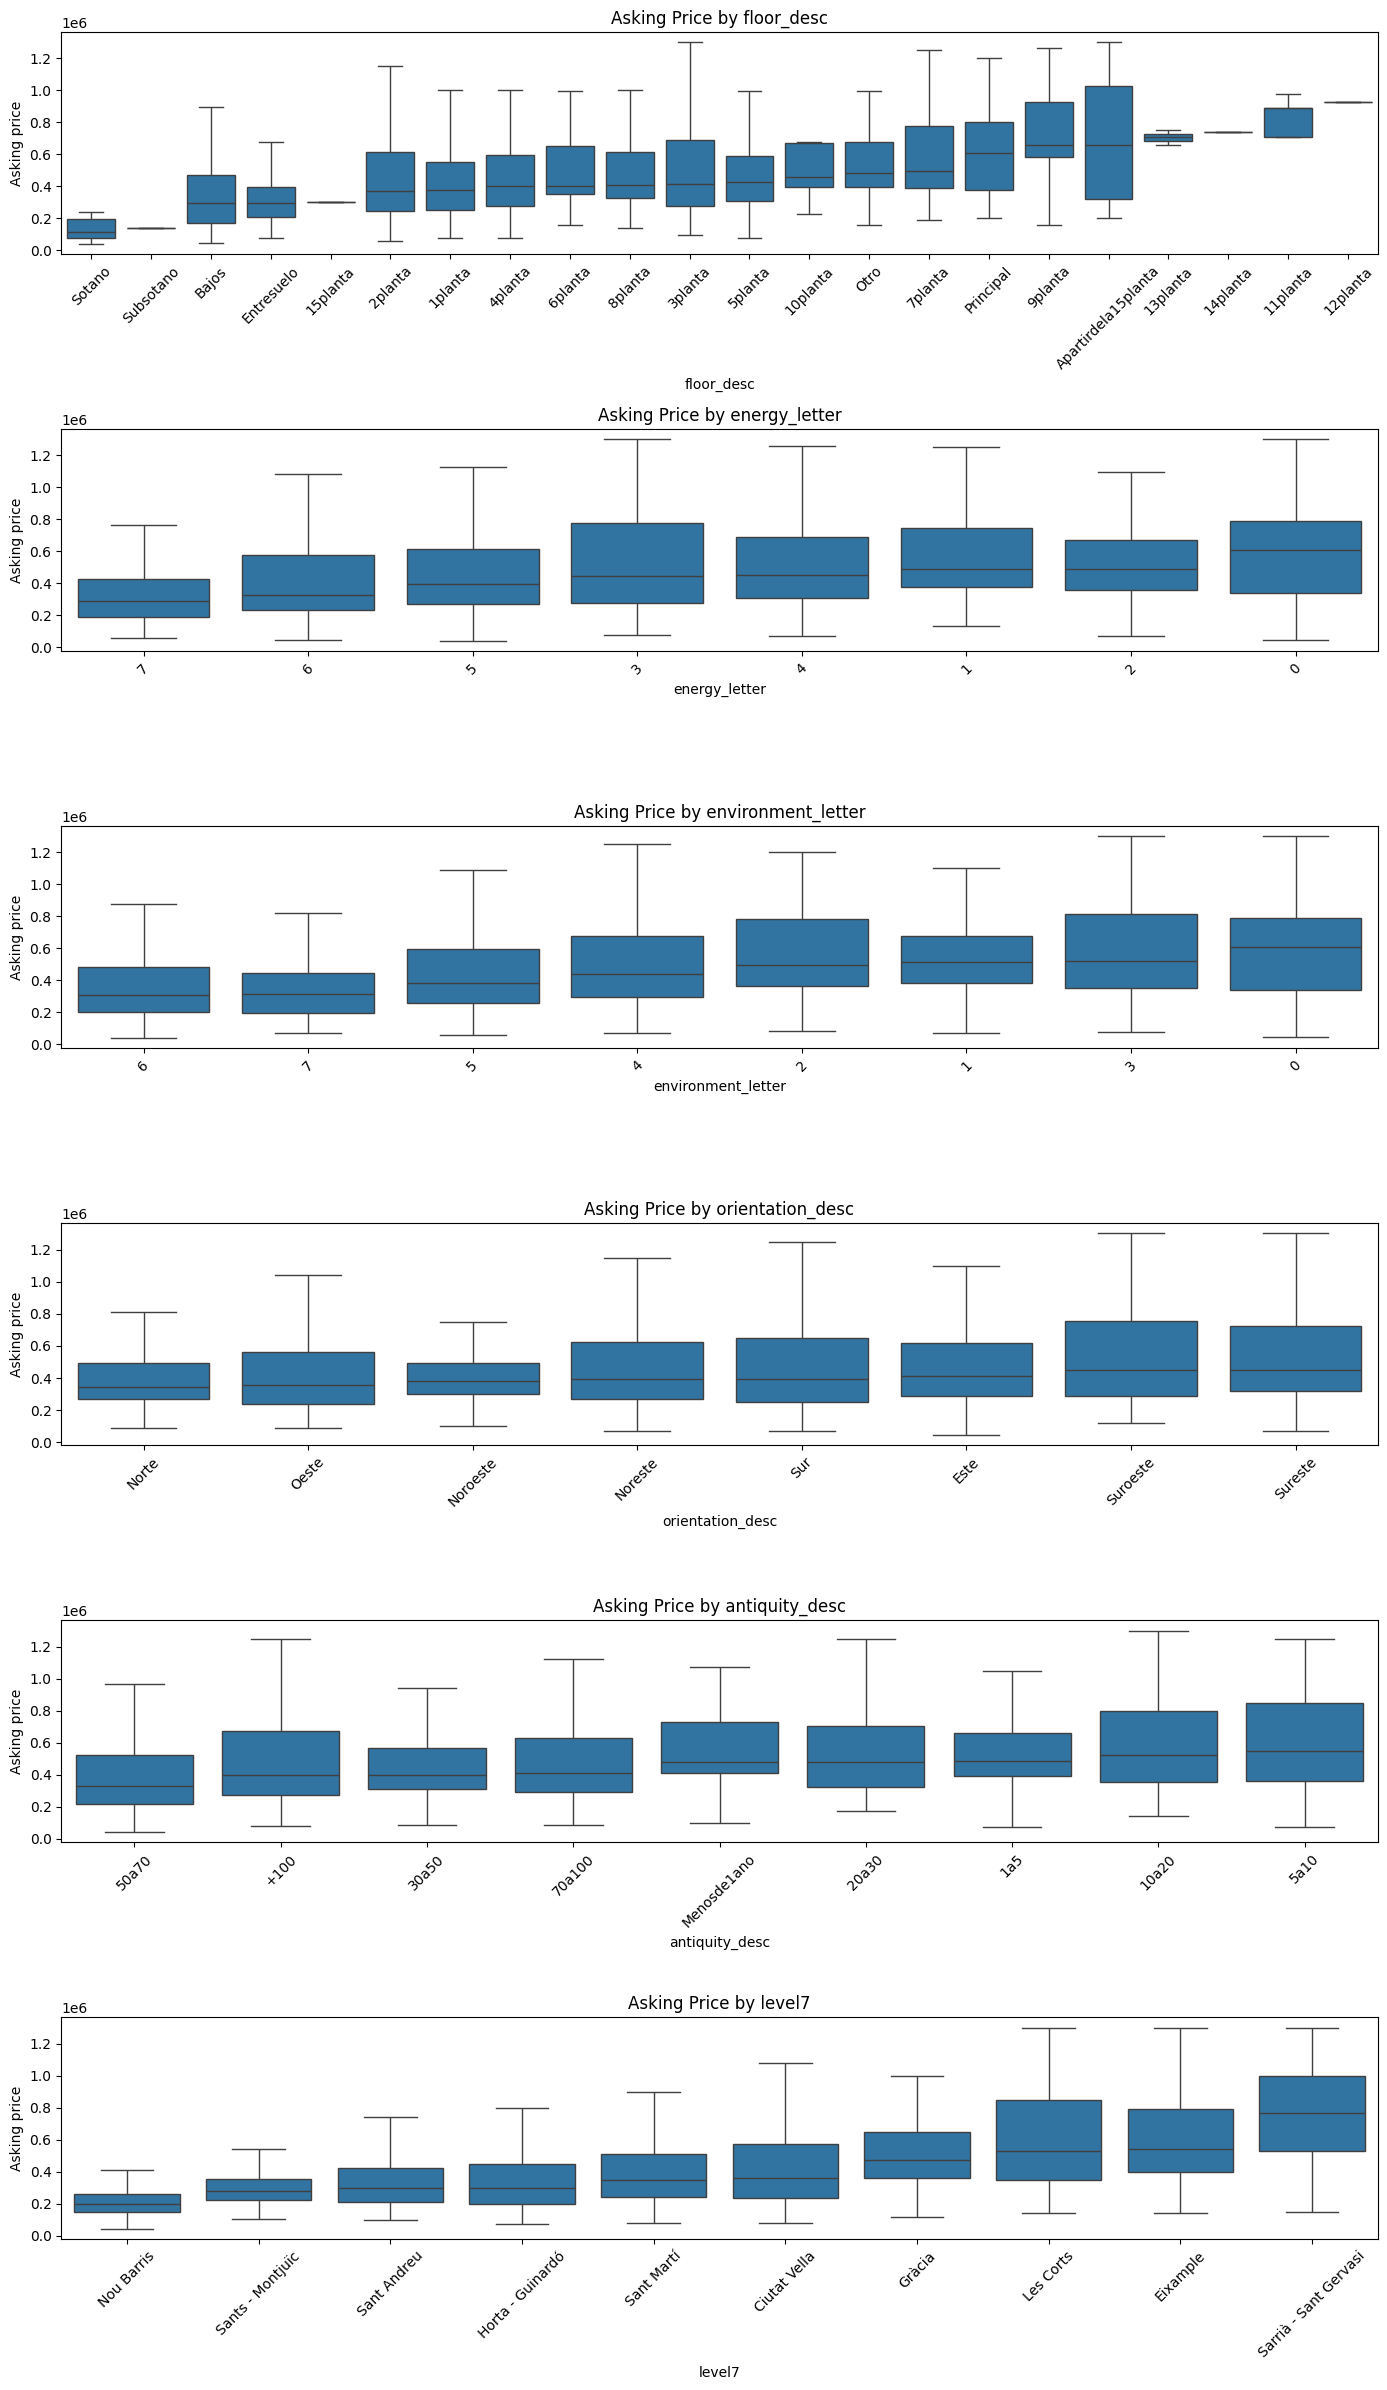

In [7]:
categorical_features = [
    "floor_desc",
    "energy_letter",
    "environment_letter",
    "orientation_desc",
    "antiquity_desc",
    "level7",
]

categorical_features = [col for col in categorical_features if col in df_model.columns]

fig, axes = plt.subplots(len(categorical_features), 1, figsize=(14, 4 * len(categorical_features)))

if len(categorical_features) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_features):
    order = df_model.groupby(col)["value"].median().sort_values().index
    sns.boxplot(data=df_model, x=col, y="value", order=order, showfliers=False, ax=ax)
    ax.set_title(f"Asking Price by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Asking price")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.5 Boolean amenities and price

The following plots compare asking price distributions for selected amenity indicators.

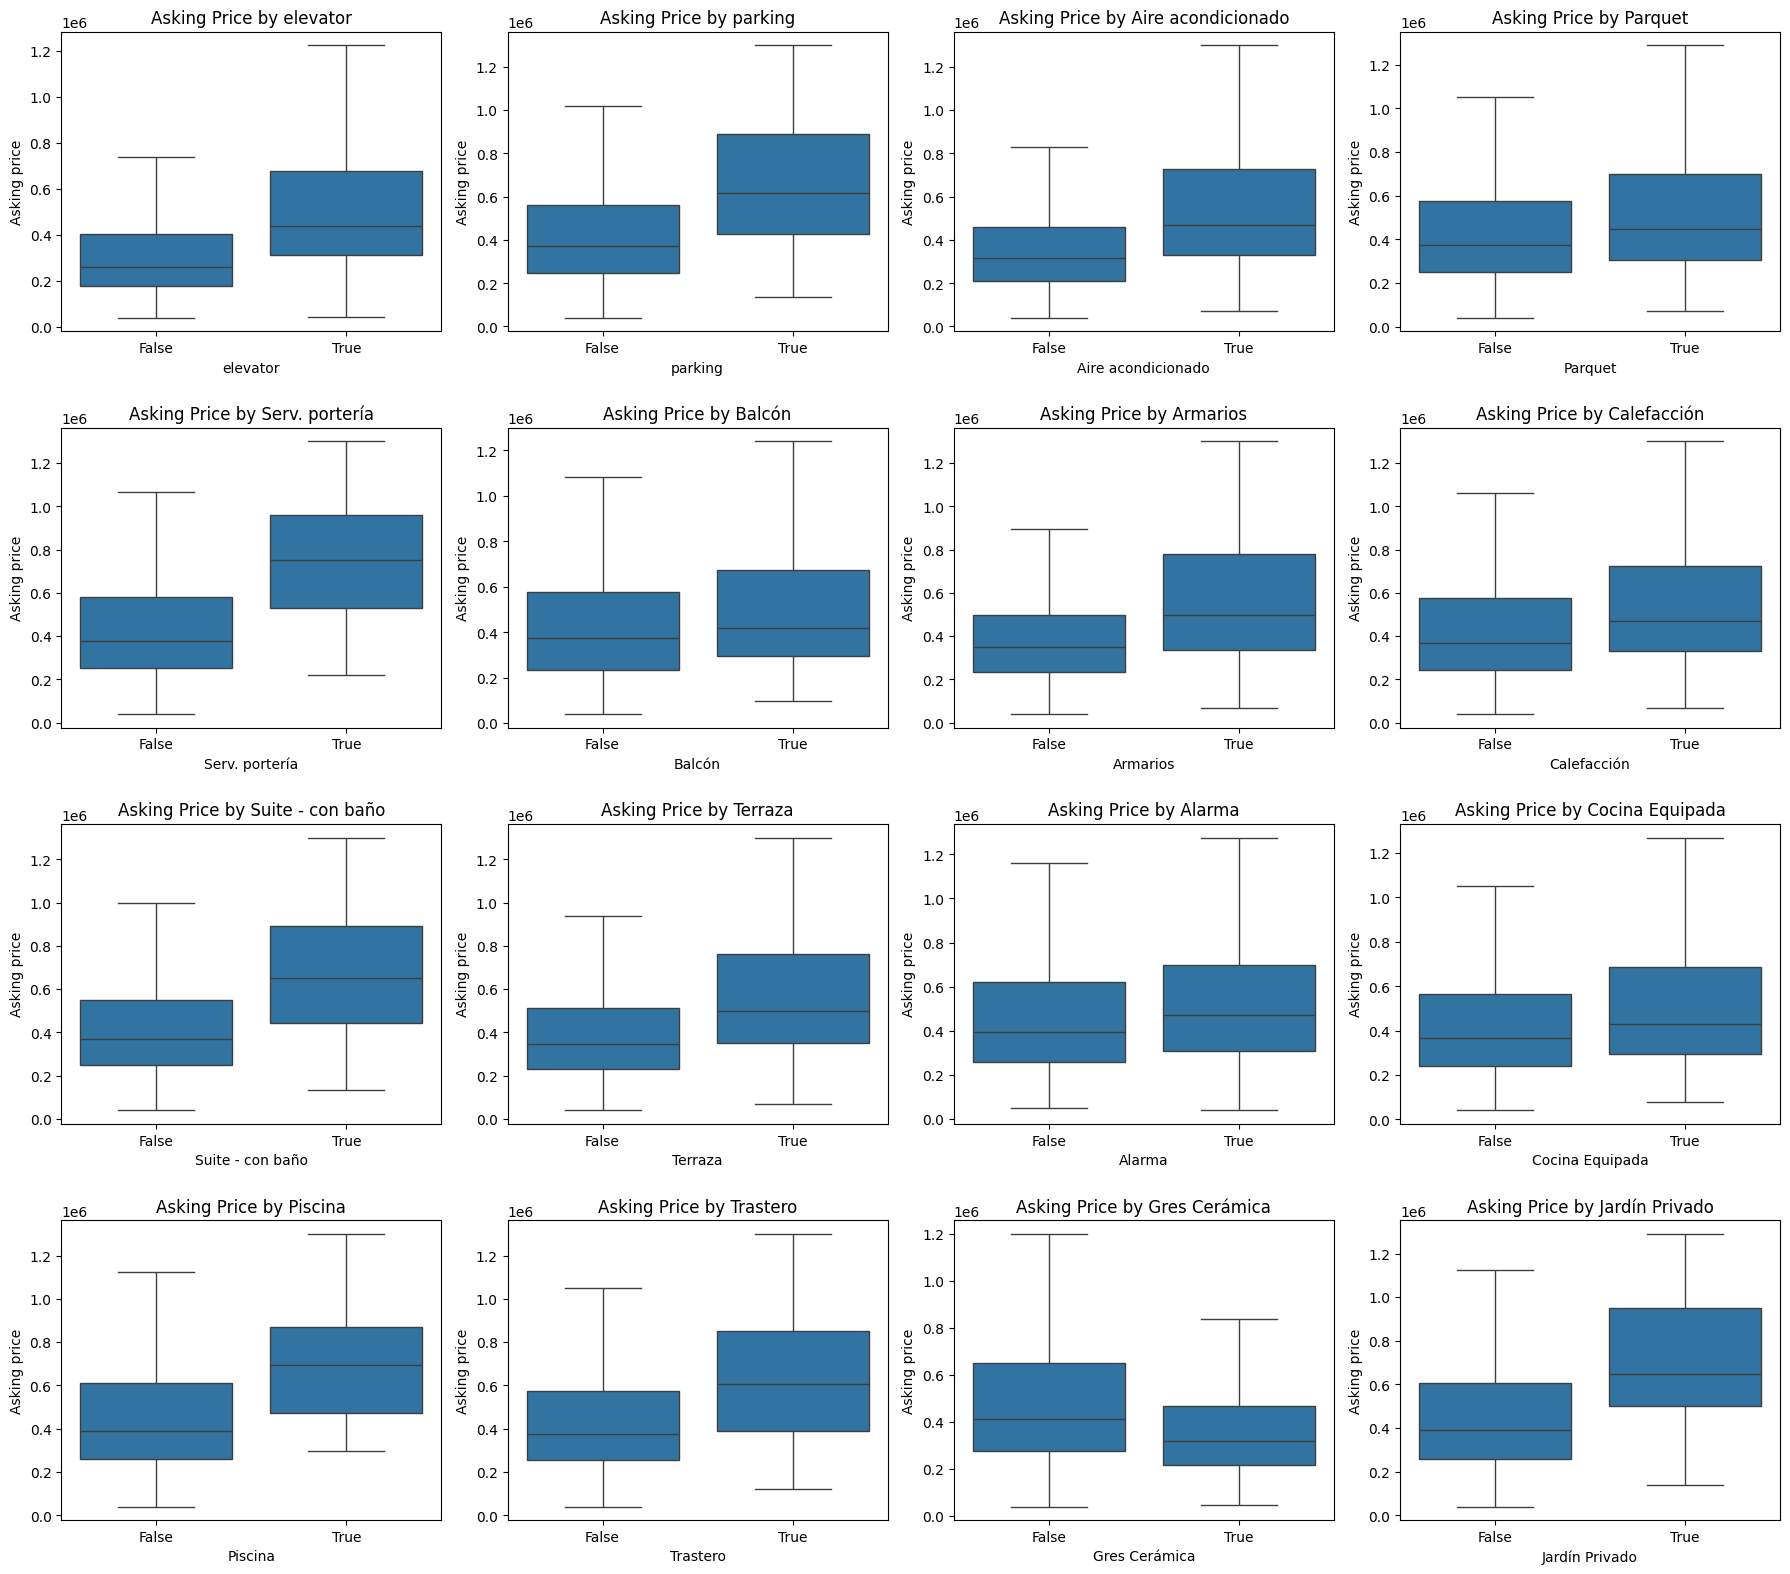

In [8]:
boolean_features = [
    "elevator",
    "parking",
    "Aire acondicionado",
    "Parquet",
    "Serv. portería",
    "Balcón",
    "Armarios",
    "Calefacción",
    "Suite - con baño",
    "Terraza",
    "Alarma",
    "Cocina Equipada",
    "Piscina",
    "Trastero",
    "Gres Cerámica",
    "Jardín Privado",
]

boolean_features = [col for col in boolean_features if col in df_model.columns]

n_cols = 4
n_rows = int(np.ceil(len(boolean_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(boolean_features):
    sns.boxplot(data=df_model, x=col, y="value", showfliers=False, ax=axes[i])
    axes[i].set_title(f"Asking Price by {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Asking price")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### 3.6 Numerical variables

This section reviews the main numerical features used by the model.

In [9]:
numeric_features = [
    "energy_value",
    "environment_value",
    "multimedia_type_2",
    "multimedia_type_6",
    "multimedia_type_12",
    "multimedia_type_21",
    "rooms",
    "bathrooms",
    "surface",
]

numeric_features = [col for col in numeric_features if col in df_model.columns]

df_model[numeric_features + ["value"]].describe()

,energy_value,environment_value,multimedia_type_2,multimedia_type_6,multimedia_type_12,multimedia_type_21,rooms,bathrooms,surface,value
count,4361.000000,4361.000000,4361.000000,591.000000,534.000000,740.000000,4361.000000,4361.000000,4361.000000,4.361000e+03
mean,150.257223,58.564309,27.606512,1.121827,1.014981,1.186486,2.853245,1.609264,99.570282,4.746849e+05
std,88.243004,124.827822,12.103006,0.422319,0.121592,0.396645,1.095662,0.730431,46.249505,2.802884e+05
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,3.990000e+04
25%,100.000000,23.000000,19.000000,1.000000,1.000000,1.000000,2.000000,1.000000,69.000000,2.615000e+05
50%,145.000000,35.000000,26.000000,1.000000,1.000000,1.000000,3.000000,2.000000,88.000000,3.950000e+05
75%,192.000000,50.000000,34.000000,1.000000,1.000000,1.000000,3.000000,2.000000,119.000000,6.300000e+05
max,960.000000,999.000000,107.000000,4.000000,2.000000,3.000000,8.000000,10.000000,515.000000,1.300000e+06


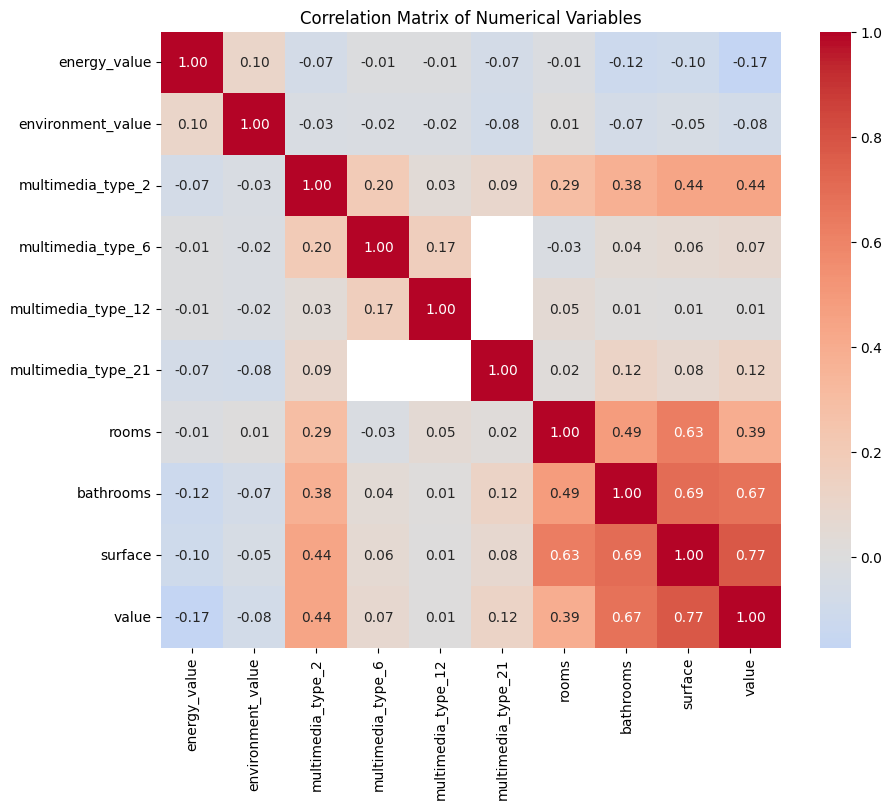

In [10]:
corr = df_model[numeric_features + ["value"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

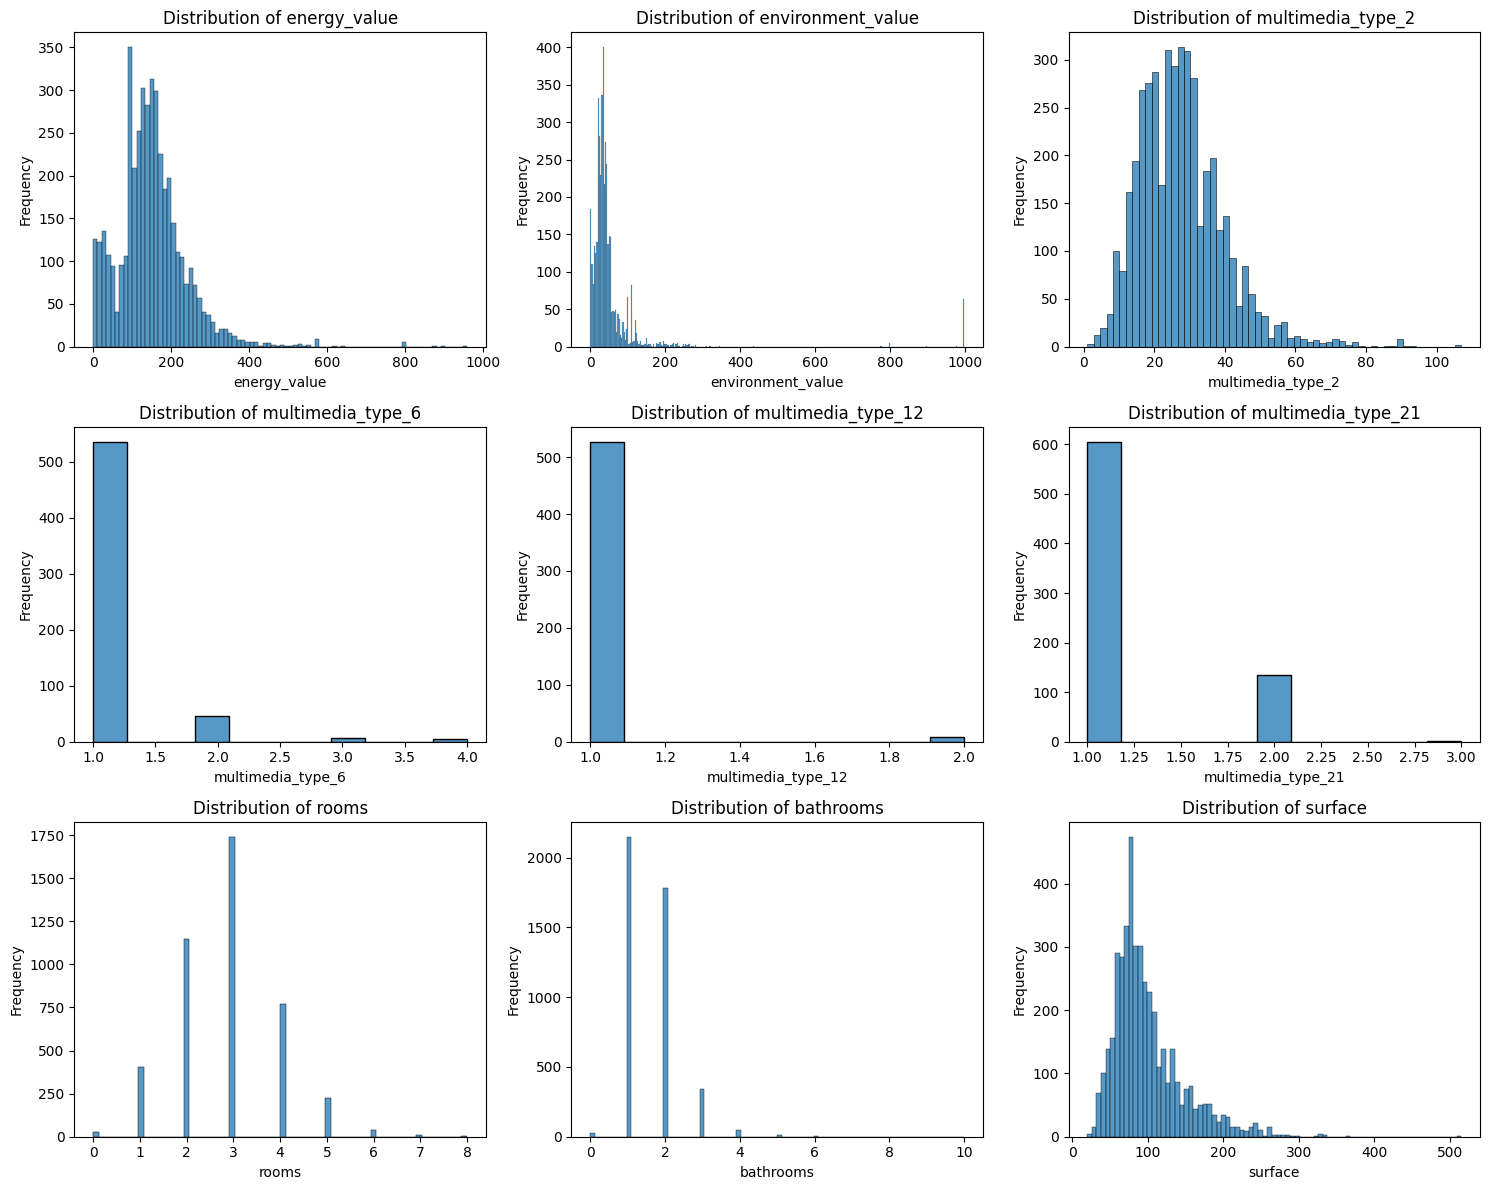

In [11]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df_model[col].dropna(), ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 4. Feature engineering

The final feature set is designed to balance predictive power and interpretability.

The selected features include property size, rooms, bathrooms, neighborhood, floor description, energy indicators, environmental indicators, and selected amenities.

Categorical variables are encoded using one-hot encoding.

In [12]:
print(f"Number of encoded features: {X_encoded.shape[1]}")
X_encoded.head()

Number of encoded features: 115


,rooms,bathrooms,surface,energy_value,environment_value,elevator,Aire acondicionado,Piscina,level8_Barri_Gotic,level8_Barri_de_les_Corts,...,floor_desc_7planta,floor_desc_8planta,floor_desc_9planta,floor_desc_Apartirdela15planta,floor_desc_Bajos,floor_desc_Entresuelo,floor_desc_Otro,floor_desc_Principal,floor_desc_Sotano,floor_desc_Subsotano
0,4,2,92,95.0,20.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,2,103,125.0,24.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,1,53,31.0,148.0,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2,1,110,159.0,36.0,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,3,1,81,109.0,35.0,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Train-test split

The dataset is split into training and test sets using an 80/20 split. The test set is kept separate for final performance evaluation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=76)
X_train.shape, X_test.shape

((3488, 115), (873, 115))

## 6. Baseline and candidate models

A baseline model is included to provide a minimum performance reference.

The candidate models are:

- Median baseline model
- Random Forest Regressor
- XGBoost Regressor

The objective is to verify that the final model provides a meaningful improvement over simpler alternatives.

In [14]:
baseline_model = train_baseline_model(X_train, y_train)
rf_model = train_random_forest_model(X_train, y_train)
xgb_model = train_xgboost_model(X_train, y_train)

models = {
    "Median baseline": baseline_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}

results = {}

for name, model in models.items():
    preds = model.predict(X_test)
    results[name] = regression_metrics(y_test, preds)

metrics_table(results)

,model,MAE,RMSE,MAPE (%),R2
0,Median baseline,211802.407789,286675.792013,53.737243,-0.077818
1,Random Forest,82584.455544,119805.668320,20.363955,0.811757
2,XGBoost,79390.023438,114840.414062,18.691326,0.827037


## 7. XGBoost optimization

The XGBoost model is optimized using randomized search with cross-validation and mean absolute error as the scoring metric.

In [15]:
best_model, best_params = optimize_xgboost_model(X_train, y_train)
best_params

Fitting 5 folds for each of 50 candidates, totalling 250 fits


{'subsample': 0.8,
 'n_estimators': 500,
 'max_depth': 7,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [16]:
best_predictions = best_model.predict(X_test)

optimized_results = {
    "Optimized XGBoost": regression_metrics(y_test, best_predictions)
}

metrics_table(optimized_results)

,model,MAE,RMSE,MAPE (%),R2
0,Optimized XGBoost,75846.960938,108420.679688,17.778513,0.845834


## 8. Model evaluation

Model evaluation focuses on both aggregate error metrics and the distribution of residuals.

Mean Absolute Error is particularly relevant because it expresses the average error in euros, making it directly interpretable.

In [18]:
eval_df = prediction_results(y_test, best_predictions)
eval_df.describe()

,actual_value,predicted_value,absolute_error,percentage_error
count,8.730000e+02,8.730000e+02,873.000000,873.000000
mean,4.720300e+05,4.716477e+05,75846.960982,17.778513
std,2.762912e+05,2.548470e+05,77518.810763,17.515232
min,3.990000e+04,6.654499e+04,128.750000,0.016975
25%,2.640000e+05,2.678180e+05,23270.421875,5.948333
50%,3.950000e+05,3.990947e+05,49993.937500,13.446978
75%,6.200000e+05,6.343525e+05,102432.843750,23.770643
max,1.300000e+06,1.270506e+06,521077.875000,207.484038


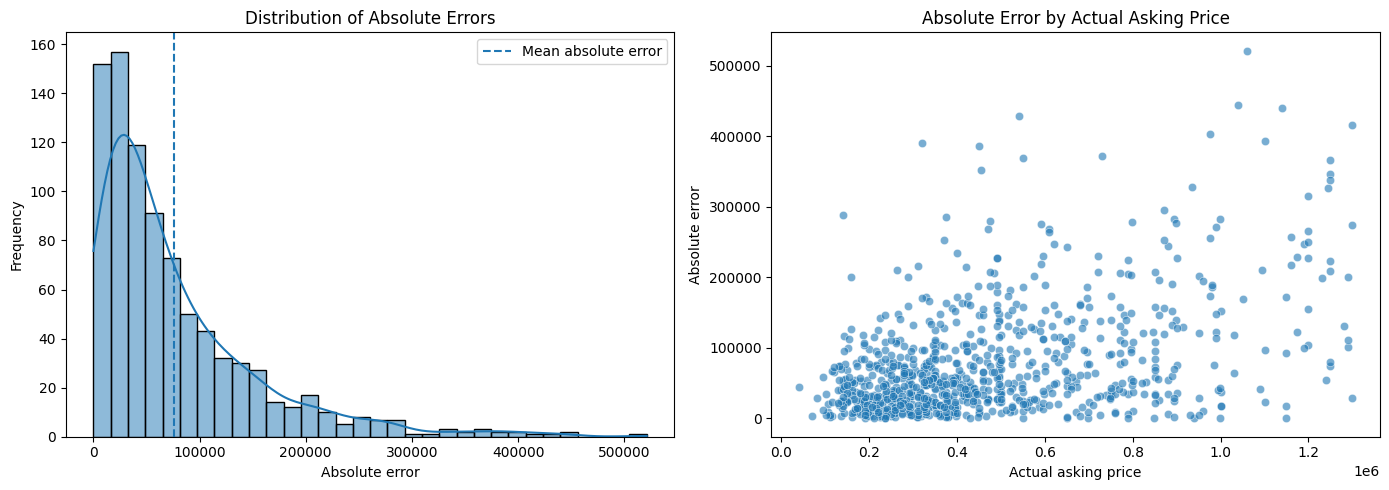

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(eval_df["absolute_error"], kde=True, ax=axes[0])
axes[0].axvline(eval_df["absolute_error"].mean(), linestyle="--", label="Mean absolute error")
axes[0].set_title("Distribution of Absolute Errors")
axes[0].set_xlabel("Absolute error")
axes[0].set_ylabel("Frequency")
axes[0].legend()

sns.scatterplot(
    x=eval_df["actual_value"],
    y=eval_df["absolute_error"],
    alpha=0.6,
    ax=axes[1],
)
axes[1].set_title("Absolute Error by Actual Asking Price")
axes[1].set_xlabel("Actual asking price")
axes[1].set_ylabel("Absolute error")

plt.tight_layout()
plt.show()

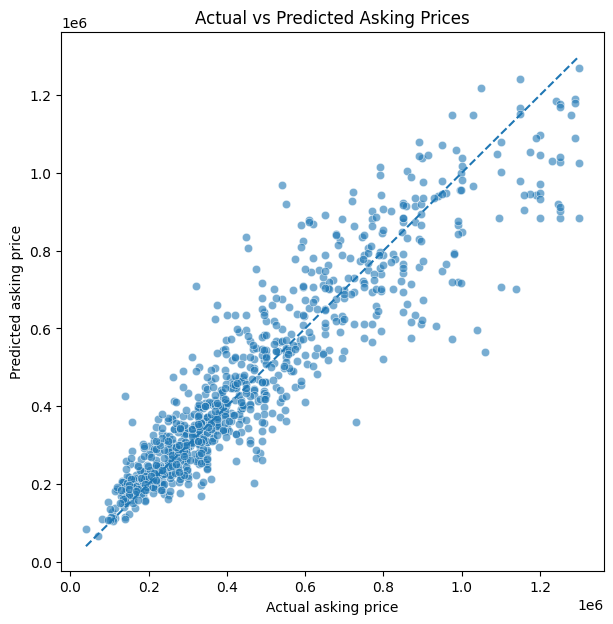

In [20]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.6)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted Asking Prices")
plt.xlabel("Actual asking price")
plt.ylabel("Predicted asking price")
plt.show()

## 9. Error analysis by price segment

Aggregate metrics can hide differences across price ranges. This section evaluates whether model error changes across market segments.

In [22]:
eval_df["price_segment"] = pd.qcut(eval_df["actual_value"], q=4, labels=["low", "mid-low", "mid-high", "high"])

segment_error = (
    eval_df
    .groupby("price_segment", observed=False)
    .agg(
        n_observations=("actual_value", "count"),
        median_actual_value=("actual_value", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        mean_percentage_error=("percentage_error", "mean"),
    )
    .reset_index()
)

segment_error

,price_segment,n_observations,median_actual_value,mean_absolute_error,median_absolute_error,mean_percentage_error
0,low,219,195000.0,42123.452554,30577.765625,23.309985
1,mid-low,224,330000.0,53350.801409,38869.750000,16.405762
2,mid-high,213,490000.0,89078.915200,66273.750000,18.017076
3,high,217,850000.0,120115.080069,96463.000000,13.378926


## 10. Feature importance

Feature importance is used to understand which variables contribute most to the model predictions.

Because one-hot encoding creates many individual geographic variables, feature importances are also grouped into broader feature families.

In [23]:
df_importance = feature_importance_table(best_model, X_train.columns)
df_importance.head(20)

,feature,importance,feature_group
0,level8_Dreta_de_l_Eixample,0.066548,neighborhood
1,surface,0.050584,surface
2,bathrooms,0.040231,bathrooms
3,level8_Torre_Baro,0.032447,neighborhood
4,level8_Diagonal_Mar_i_el_Front_Maritim_del_Pob...,0.029576,neighborhood
5,elevator,0.024382,elevator
6,level8_La_Marina_del_Prat_Vermell,0.024258,neighborhood
7,level8_Les_Roquetes,0.023475,neighborhood
8,level8_Sarria,0.023000,neighborhood
9,level8_L_Antiga_Esquerra_de_l_Eixample,0.021118,neighborhood


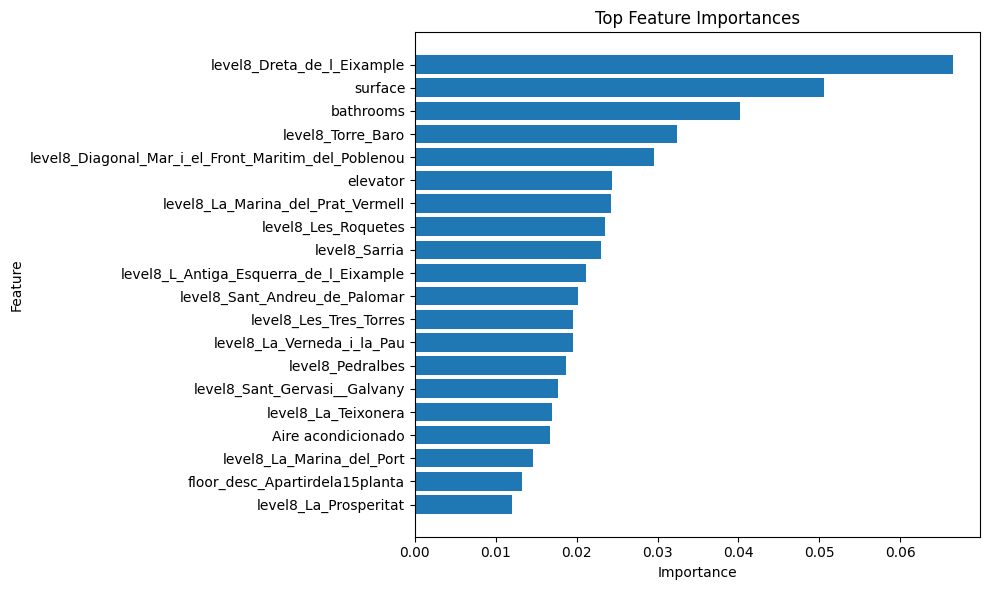

In [25]:
top_n = 20

plt.figure(figsize=(10, 6))
plt.barh(
    df_importance.head(top_n)["feature"][::-1],
    df_importance.head(top_n)["importance"][::-1],
)
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

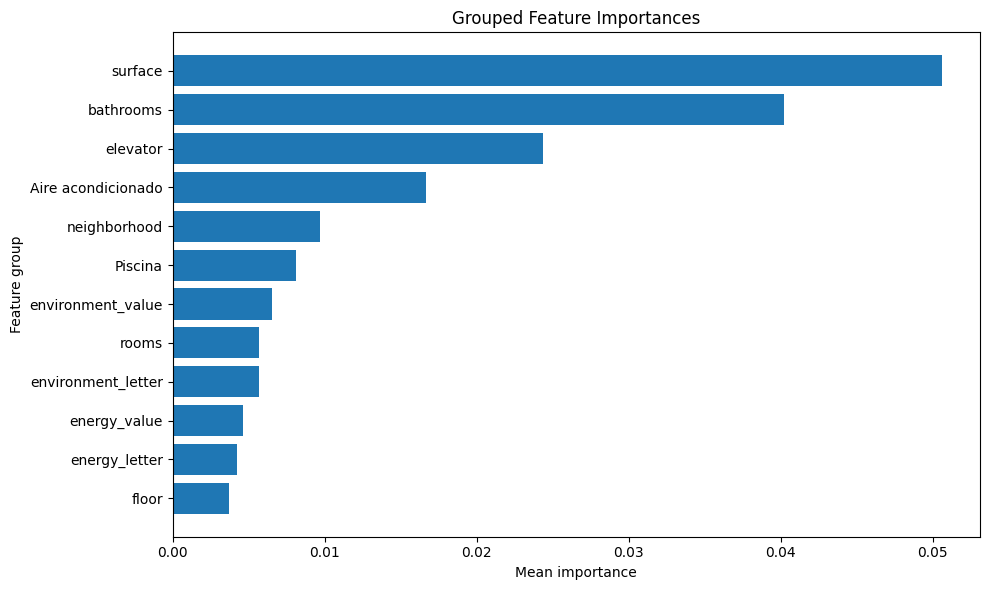

,feature_group,importance
11,surface,0.050584
2,bathrooms,0.040231
3,elevator,0.024382
0,Aire acondicionado,0.016668
9,neighborhood,0.009662
1,Piscina,0.008128
7,environment_value,0.006558
10,rooms,0.005681
6,environment_letter,0.005670
5,energy_value,0.004598


In [26]:
df_grouped_importance = grouped_feature_importance(df_importance)

plt.figure(figsize=(10, 6))
plt.barh(
    df_grouped_importance["feature_group"][::-1],
    df_grouped_importance["importance"][::-1],
)
plt.title("Grouped Feature Importances")
plt.xlabel("Mean importance")
plt.ylabel("Feature group")
plt.tight_layout()
plt.show()

df_grouped_importance

## 11. Save model artifact

The optimized model is saved as a reusable artifact for downstream analysis.

In [27]:
from src.paths import ROOT_DIR

model_path = ROOT_DIR / "models" / "flat_prices_model.pkl"
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(best_model, file)

model_path

PosixPath('/Users/josep/Documents/projects/barcelona-housing-market-analysis/models/flat_prices_model.pkl')

## 12. Example prediction

The following example shows how the trained model can be used to estimate the asking price of a new property after applying the same feature encoding structure used during training.

This is included only as a technical validation of the modeling pipeline, not as a production application.

In [28]:
X_new = pd.DataFrame(columns=X_train.columns)

new_row = {
    "rooms": 4,
    "bathrooms": 2,
    "surface": 95,
    "energy_value": 100,
    "environment_value": 100,
    "elevator": True,
    "Aire acondicionado": True,
    "Piscina": False,
}

dummy_values = {col: False for col in X_train.columns}
dummy_values.update(new_row)

example_categories = [
    "level8_El_Camp_de_l_Arpa_del_Clot",
    "energy_letter_4",
    "environment_letter_3",
    "floor_desc_4planta",
]

for col in example_categories:
    if col in dummy_values:
        dummy_values[col] = True

X_new = pd.DataFrame([dummy_values])
X_new = X_new[X_train.columns]

predicted_price = best_model.predict(X_new)[0]

print(f"Estimated asking price: {predicted_price:,.0f} €")

Estimated asking price: 407,846 €


## 13. Module output

This module produces:

- a trained valuation model
- model performance metrics
- residual and segment-level error analysis
- feature importance analysis
- a reusable model artifact saved in `models/flat_prices_model.pkl`

The model estimates asking prices based on listing characteristics. Its outputs should be interpreted as model-based estimates of advertised market value, not as final transaction prices.